# AI-Powered News Verification System

## Project Overview

This project aims to classify news articles as **Fake News** or **Real News** using Natural Language Processing (NLP) and Machine Learning techniques.

The workflow includes:

- Data Collection
- Exploratory Data Analysis (EDA)
- Text Preprocessing
- Feature Engineering using TF-IDF
- Model Training and Evaluation
- Model Comparison
- Model Persistence

The final objective is to build a reliable news verification system capable of identifying misinformation.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Collection and Loading

The dataset consists of two separate files:

- **Fake.csv** containing fake news articles.
- **True.csv** containing real news articles.

Both datasets are loaded into Pandas DataFrames for further analysis.

In [3]:
# READ DATASET
fake = pd.read_csv("data\Fake.csv")
true = pd.read_csv("data\True.csv")

In [4]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


# 2. Dataset Overview

This section examines the size of both datasets and provides an initial understanding of the available records.

In [6]:
# DATASET SIZE
print(fake.shape)
print(true.shape)

(23481, 4)
(21417, 4)


# 3. Creating Target Labels

To perform supervised machine learning, target labels are assigned:

- 0 → Fake News
- 1 → Real News

These labels will be used as the prediction target.

In [7]:
# ADD LABELS
fake["label"] = 0
true["label"] = 1


# 4. Dataset Merging

The fake and real news datasets are combined into a single DataFrame to simplify analysis and model development.

In [8]:
# MERGE
df = pd.concat([fake, true], ignore_index = True)

In [9]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


# 5. Data Quality Assessment

Before analysis, it is important to verify:

- Dataset structure
- Data types
- Missing values

This helps ensure data quality and consistency.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [11]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [12]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

# 6. Fake vs Real News Distribution

This visualization shows the distribution of fake and real news articles within the dataset.

A balanced dataset generally improves model performance and reduces prediction bias.

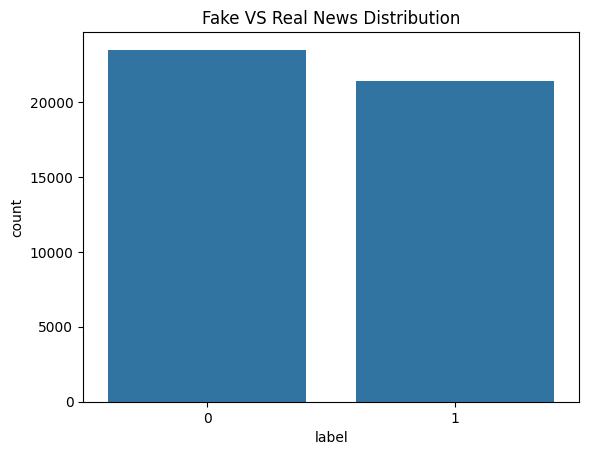

In [12]:
# visualization
sns.countplot(x = "label", data = df)
plt.title("Fake VS Real News Distribution")
plt.show()

# 7. Subject Analysis

This section explores the distribution of news categories and identifies the most common topics present in the dataset.

In [13]:
# Which subjects appear most frequently?

df['subject'].value_counts()

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

## Subject Distribution Visualization

The following chart highlights the frequency of different news subjects.

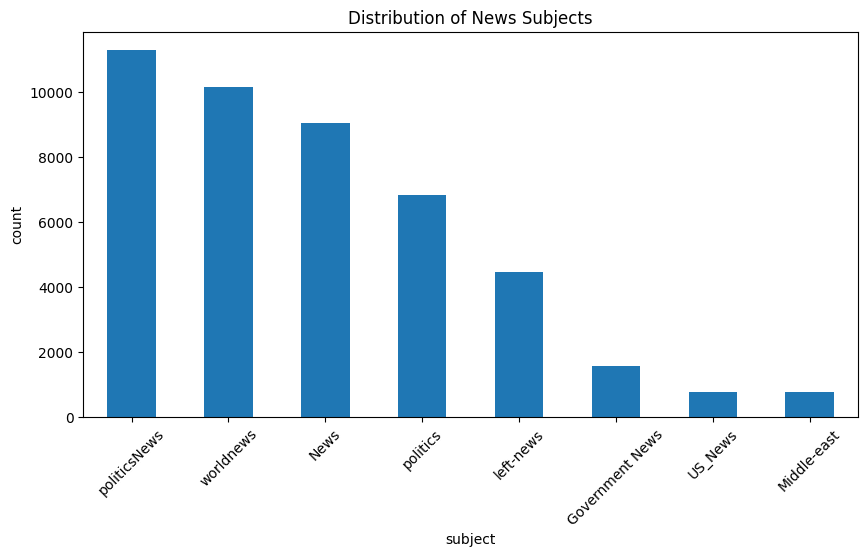

In [14]:
# visulization

plt.figure(figsize = (10, 5))
df['subject'].value_counts().plot(kind = 'bar')
plt.title('Distribution of News Subjects')
plt.xlabel('subject')
plt.ylabel('count')
plt.xticks(rotation = 45)
plt.show()

# 8. Article Length Analysis

Article length can provide useful insights into writing patterns.

This section measures the length of each article and explores the overall distribution.

In [15]:
df['article_length'] = df['text'].apply(len)

In [16]:
df['article_length'].describe()

count    44898.000000
mean      2469.109693
std       2171.617091
min          1.000000
25%       1234.000000
50%       2186.000000
75%       3105.000000
max      51794.000000
Name: article_length, dtype: float64

## Article Length Comparison

This visualization compares article lengths between fake and real news articles.

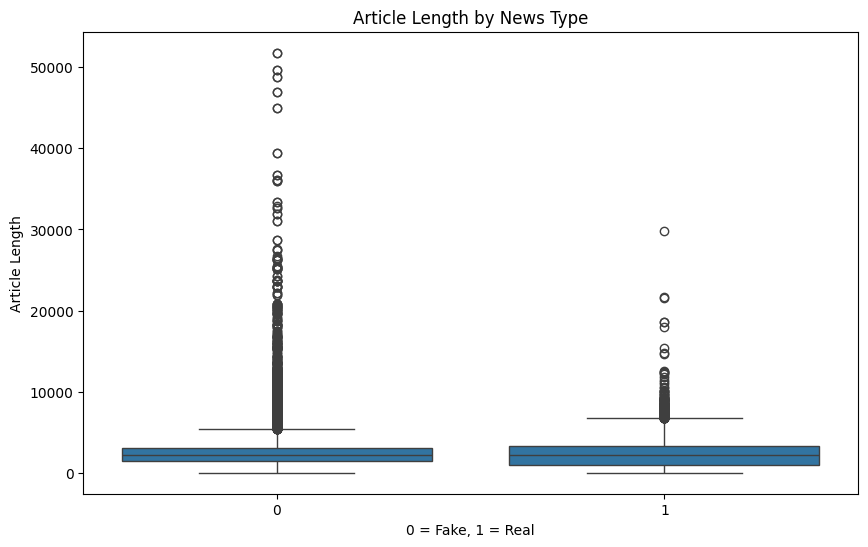

In [17]:
# Are fake news articles shorter or longer than real news articles?

plt.figure(figsize = (10, 6))

sns.boxplot(
    x = 'label',
    y = 'article_length',
    data = df
)

plt.title('Article Length by News Type')
plt.xlabel('0 = Fake, 1 = Real')
plt.ylabel('Article Length')
plt.show()

## Distribution of Article Length

The histogram below illustrates the overall spread of article lengths across the dataset.

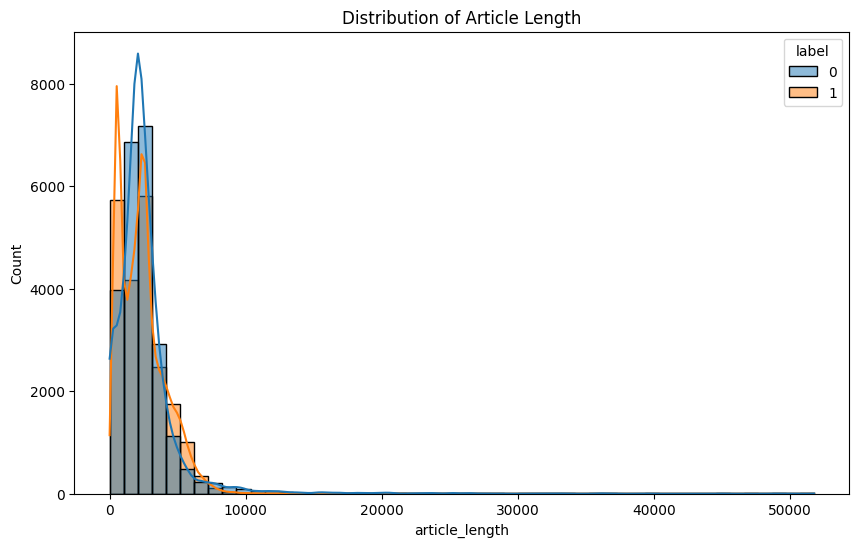

In [18]:
plt.figure(figsize = (10, 6))

sns.histplot(
    data = df,
    x = 'article_length',
    hue = 'label',
    bins = 50,
    kde = True
)

plt.title("Distribution of Article Length")
plt.show()

# 9. Word Frequency Analysis

Word Clouds provide a visual representation of the most frequently occurring words within news articles.

This helps identify dominant terms and patterns in fake and real news content.

## Fake News Word Cloud

The following word cloud displays the most frequently used terms in fake news articles.

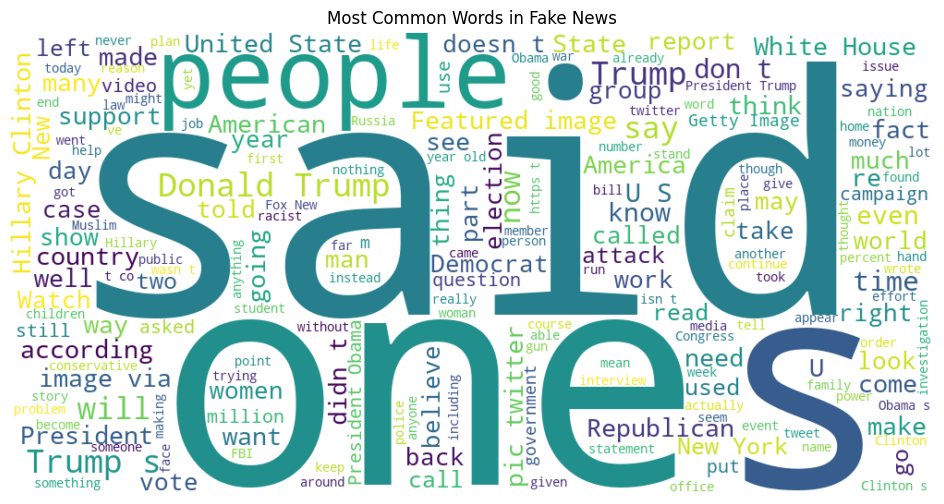

In [19]:
# Fake News Word Cloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = " ".join(df[df['label'] == 0]['text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Fake News")
plt.show()

## Real News Word Cloud

The following word cloud displays the most frequently used terms in real news articles.

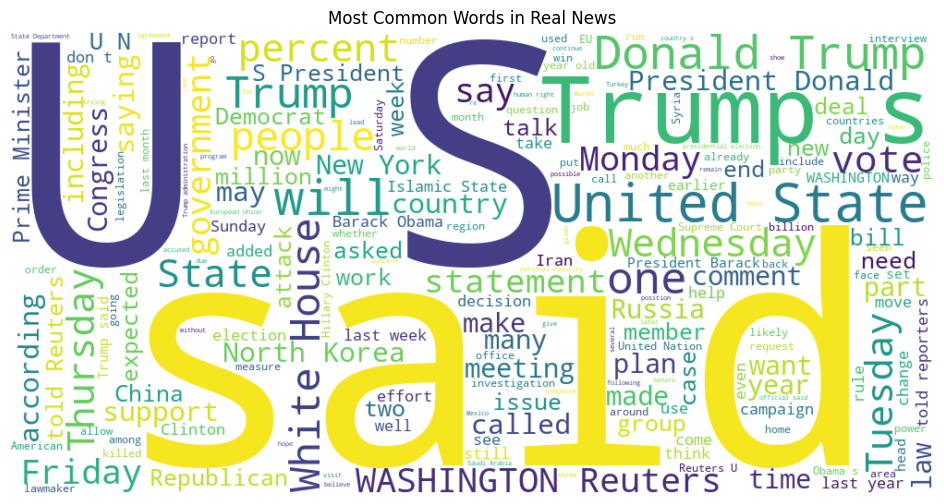

In [20]:
# Real News Word Cloud
real_text = " ".join(df[df['label'] == 1]['text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(real_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Real News")
plt.show()

In [21]:
# Text Preprocessing
import re
import string

# 10. Text Preprocessing

Raw textual data often contains:

- URLs
- Punctuation
- Numbers
- Extra spaces

Cleaning the text improves the quality of features extracted by machine learning algorithms.

In [22]:
# Create Cleaning Function
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'www\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

## Text Cleaning Execution

The cleaning function is applied to all news articles to generate a processed text column.

In [23]:
# Apply Cleaning

df['clean_text'] = df['text'].apply(clean_text)

In [24]:
df[['text','clean_text']].head()

,text,clean_text
0,Donald Trump just couldn t wish all Americans ...,donald trump just couldn t wish all americans ...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",on friday it was revealed that former milwauke...
3,"On Christmas day, Donald Trump announced that ...",on christmas day donald trump announced that h...
4,Pope Francis used his annual Christmas Day mes...,pope francis used his annual christmas day mes...


# 11. Dataset Splitting

The dataset is divided into training and testing sets.

- Training Set: 80%
- Testing Set: 20%

This allows model evaluation on unseen data.

In [25]:
# Train-Test Split
X = df['clean_text']
y = df['label']

In [26]:
# Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
# Check Shapes
print(X_train.shape)
print(X_test.shape)

(35918,)
(8980,)


# 12. Feature Engineering using TF-IDF

Machine learning algorithms require numerical input.

TF-IDF (Term Frequency-Inverse Document Frequency) converts textual data into numerical feature vectors while emphasizing important words.

In [28]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
# Create Vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

In [30]:
# Transform Data
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [31]:
# Check Shape
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(35918, 10000)
(8980, 10000)


# 13. Machine Learning Model Development

Multiple machine learning algorithms are trained and evaluated:

- Logistic Regression
- Multinomial Naive Bayes
- Random Forest

The objective is to identify the best-performing model for fake news classification.

In [32]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_tfidf, y_train)

pred_lr = lr.predict(X_test_tfidf)

In [33]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.987305122494432


# 14. Model Evaluation

Model performance is assessed using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

These metrics provide a comprehensive evaluation of classification quality.

In [34]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4733
           1       0.99      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



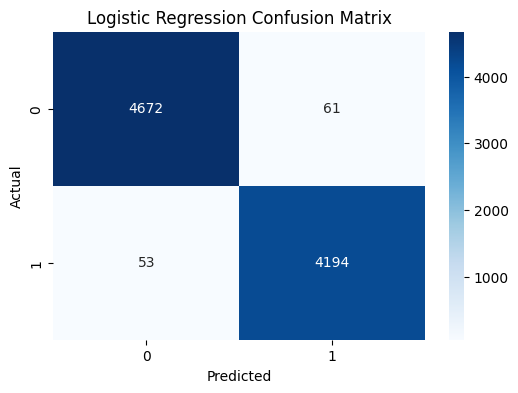

In [35]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [36]:
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

pred_nb = nb.predict(X_test_tfidf)

accuracy_nb = accuracy_score(y_test, pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.926837416481069


In [37]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)

pred_rf = rf.predict(X_test_tfidf)

accuracy_rf = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9956570155902005


# 15. Model Comparison

The performance of all trained models is compared to determine the most effective classifier.

In [38]:
# Comparison Table
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_nb,
        accuracy_rf
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.987305
1,Naive Bayes,0.926837
2,Random Forest,0.995657


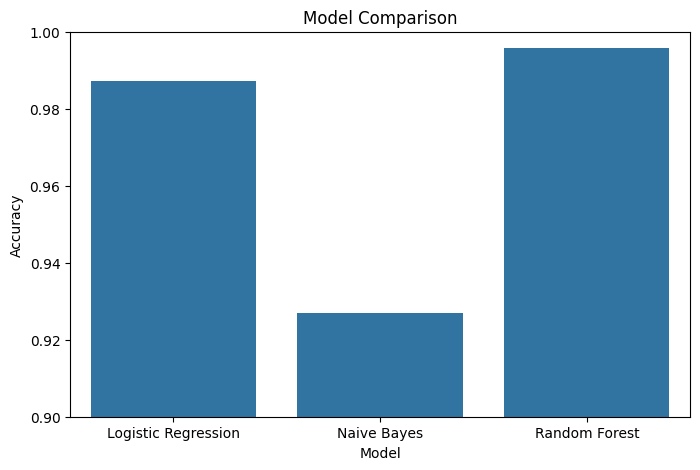

In [39]:
# Visualize Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Model Comparison")

plt.ylim(0.9,1.0)

plt.show()

# 16. Model Persistence

The best-performing model and TF-IDF vectorizer are saved using Joblib.

This enables future deployment without retraining the model.

In [40]:
# Save the Best Model
import joblib

joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [41]:
# Test Loading
loaded_model = joblib.load("random_forest_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [42]:
sample_news = ["Breaking news example article"]

sample_vector = loaded_vectorizer.transform(sample_news)

prediction = loaded_model.predict(sample_vector)

print(prediction)

[0]


In [43]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [44]:
import os

os.listdir()

['data',
 'EDA.ipynb',
 'model',
 'notebook',
 'random_forest_model.pkl',
 'requirements.txt',
 'tfidf_vectorizer.pkl']

# Conclusion

## Key Findings

- The dataset contains 44,898 news articles.
- Political and world news dominate the dataset.
- Text preprocessing significantly improved data quality.
- TF-IDF successfully converted text into machine-readable features.
- Random Forest achieved the highest accuracy of approximately 99.57%.
- The trained model is suitable for deployment in a News Verification System.

## Future Enhancements

- Streamlit Web Application
- Confidence Score Predictions
- News Source Reliability Analysis
- Prediction History Tracking
- Cloud Deployment